In [3]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=UserWarning)

# Prefer workspace root (one level above notebooks) for stable paths.
ROOT = (Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve())
if not (ROOT / "data" / "processed").exists():
    raise FileNotFoundError(f"Could not locate data/processed from ROOT={ROOT}")

DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"; MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = ROOT / "reports"; REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR = REPORT_DIR / "figures"; FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
BRIER_TARGET = 0.14

def load_target(path):
    """Same index-safety helper as Phase 2's features.py — target is always the last column."""
    df = pd.read_csv(path)
    return (df.iloc[:, -1] if df.shape[1] > 1 else df.iloc[:, 0]).astype(int).values

X_train = pd.read_csv(DATA_DIR / "X_train_encoded.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test_encoded.csv")
y_train = load_target(DATA_DIR / "y_train.csv")
y_test  = load_target(DATA_DIR / "y_test.csv")

print(f"ROOT: {ROOT}")
print(f"X_train {X_train.shape}, X_test {X_test.shape}")
print(f"y_train {y_train.shape}, y_test {y_test.shape}")

ROOT: /home/yon/churn_project
X_train (5634, 28), X_test (1409, 28)
y_train (5634,), y_test (1409,)


In [4]:
assert X_train.shape[0] == len(y_train), "X_train/y_train row mismatch — re-check Phase 2 handoff"
assert X_test.shape[0] == len(y_test), "X_test/y_test row mismatch"
assert X_train.shape[1] == X_test.shape[1], "train/test column mismatch — encoding drift between splits"
assert not X_train.isna().any().any(), "NaNs in X_train — imputer step may have been skipped"
assert not X_test.isna().any().any(), "NaNs in X_test"
assert set(np.unique(y_train)) == {0, 1}, "y_train is not binary — check load_target()"

neg, pos = np.bincount(y_train)
churn_rate = pos / (pos + neg)
print(f"Train churn rate: {churn_rate:.4f}  (expect ~0.265, per project spec)")
assert 0.24 < churn_rate < 0.29, "Train churn rate drifted from expected ~26.5% — check the split"

print("Phase 2 handoff verified. Proceeding.")

Train churn rate: 0.2654  (expect ~0.265, per project spec)
Phase 2 handoff verified. Proceeding.


In [5]:
baseline = LGBMClassifier(objective="binary", random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
baseline.fit(X_train, y_train)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

print(f"Baseline Brier: {brier_score_loss(y_test, baseline_prob):.4f}")
print(f"Baseline Log-Loss: {log_loss(y_test, baseline_prob):.4f}")
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, baseline_prob):.4f}")

Baseline Brier: 0.1427
Baseline Log-Loss: 0.4411
Baseline ROC-AUC: 0.8306


In [6]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight computed: {scale_pos_weight:.3f}")

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, -1],
    "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0],
    "scale_pos_weight": [1.0, scale_pos_weight],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base = LGBMClassifier(objective="binary", random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

search = RandomizedSearchCV(
    base, param_dist, n_iter=40, scoring="neg_brier_score",
    cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)

t0 = time.time()
search.fit(X_train, y_train)
print(f"Search done in {time.time()-t0:.1f}s")
print(f"Best CV neg_brier_score: {search.best_score_:.5f}")
print(json.dumps(search.best_params_, indent=2))

tuned_model = search.best_estimator_
tuned_model.fit(X_train, y_train)  # refit on full train set

scale_pos_weight computed: 2.769
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Search done in 41.5s
Best CV neg_brier_score: -0.13451
{
  "subsample": 0.9,
  "scale_pos_weight": 1.0,
  "reg_lambda": 1.0,
  "reg_alpha": 0.1,
  "num_leaves": 15,
  "n_estimators": 300,
  "min_child_samples": 20,
  "max_depth": 3,
  "learning_rate": 0.03,
  "colsample_bytree": 0.8
}


,num_leaves,15
,max_depth,3
,learning_rate,0.03
,n_estimators,300
,objective,'binary'
,subsample,0.9
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1


In [7]:
cal_sigmoid = CalibratedClassifierCV(estimator=tuned_model, method="sigmoid", cv=cv)
cal_isotonic = CalibratedClassifierCV(estimator=tuned_model, method="isotonic", cv=cv)

print("Fitting sigmoid (Platt) calibration...")
cal_sigmoid.fit(X_train, y_train)

print("Fitting isotonic calibration...")
cal_isotonic.fit(X_train, y_train)

print("Both calibration methods fit.")

Fitting sigmoid (Platt) calibration...
Fitting isotonic calibration...
Both calibration methods fit.


In [8]:
cal_sigmoid = CalibratedClassifierCV(estimator=tuned_model, method="sigmoid", cv=cv)
cal_isotonic = CalibratedClassifierCV(estimator=tuned_model, method="isotonic", cv=cv)

print("Fitting sigmoid (Platt) calibration...")
cal_sigmoid.fit(X_train, y_train)

print("Fitting isotonic calibration...")
cal_isotonic.fit(X_train, y_train)

print("Both calibration methods fit.")

Fitting sigmoid (Platt) calibration...
Fitting isotonic calibration...
Both calibration methods fit.


In [9]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi) if lo > 0 else (y_prob >= lo) & (y_prob <= hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece

def evaluate(name, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "brier_score": brier_score_loss(y_test, y_prob),
        "log_loss": log_loss(y_test, y_prob),
        "ece": expected_calibration_error(np.asarray(y_test), y_prob),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "avg_precision": average_precision_score(y_test, y_prob),
    }, y_prob

m_uncal, prob_uncal = evaluate("uncalibrated_tuned", tuned_model, X_test, y_test)
m_sig, prob_sigmoid = evaluate("platt_sigmoid", cal_sigmoid, X_test, y_test)
m_iso, prob_isotonic = evaluate("isotonic", cal_isotonic, X_test, y_test)

metrics_df = pd.DataFrame([m_uncal, m_sig, m_iso]).sort_values("brier_score")
print(metrics_df.to_string(index=False))

best = metrics_df.iloc[0]
gate_passed = best["brier_score"] < BRIER_TARGET
print(f"\nGATE: best = {best['model']} | Brier = {best['brier_score']:.4f} "
      f"| target < {BRIER_TARGET} | {'PASSED — KKBox unlocked' if gate_passed else 'NOT MET'}")

             model  brier_score  log_loss      ece  roc_auc  avg_precision
     platt_sigmoid     0.135129  0.414510 0.011219 0.846383       0.662789
uncalibrated_tuned     0.135317  0.414736 0.013859 0.846192       0.664785
          isotonic     0.135708  0.417729 0.022748 0.845633       0.660050

GATE: best = platt_sigmoid | Brier = 0.1351 | target < 0.14 | PASSED — KKBox unlocked


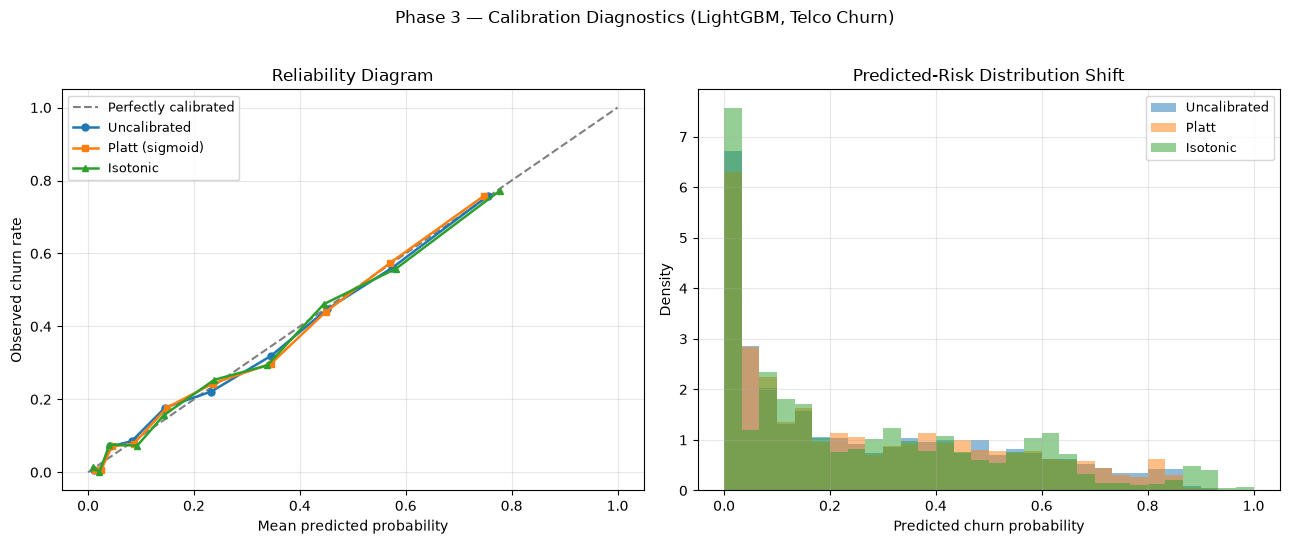

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
for label, probs, style in [
    ("Uncalibrated", prob_uncal, "o-"),
    ("Platt (sigmoid)", prob_sigmoid, "s-"),
    ("Isotonic", prob_isotonic, "^-"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, style, label=label, linewidth=1.8, markersize=5)
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed churn rate")
ax.set_title("Reliability Diagram"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax2 = axes[1]
bins = np.linspace(0, 1, 31)
for label, probs in [("Uncalibrated", prob_uncal), ("Platt", prob_sigmoid), ("Isotonic", prob_isotonic)]:
    ax2.hist(probs, bins=bins, alpha=0.5, label=label, density=True)
ax2.set_xlabel("Predicted churn probability"); ax2.set_ylabel("Density")
ax2.set_title("Predicted-Risk Distribution Shift"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

fig.suptitle("Phase 3 — Calibration Diagnostics (LightGBM, Telco Churn)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "phase3_calibration_diagnostics.png", dpi=200)
plt.show()

In [12]:
joblib.dump(tuned_model, MODEL_DIR / "lgbm_base_tuned.pkl")
joblib.dump(cal_sigmoid, MODEL_DIR / "lgbm_calibrated_sigmoid.pkl")
joblib.dump(cal_isotonic, MODEL_DIR / "lgbm_calibrated_isotonic.pkl")
metrics_df.to_csv(REPORT_DIR / "phase3_calibration_metrics.csv", index=False)

print("Saved: 3 model artifacts + phase3_calibration_metrics.csv")

Saved: 3 model artifacts + phase3_calibration_metrics.csv


In [13]:
with open(REPORT_DIR / "phase3_model_card_inputs.md", "w") as f:
    f.write("# Phase 3 Model Card Inputs (raw numbers)\n\n")
    f.write(f"- Best LightGBM hyperparameters:\n```json\n{json.dumps(search.best_params_, indent=2)}\n```\n\n")
    f.write(f"- Chosen calibration method: **{best['model']}**\n")
    f.write(f"- Brier Score Loss: {best['brier_score']:.4f} (target < {BRIER_TARGET}, "
            f"{'PASSED' if gate_passed else 'NOT MET'})\n")
    f.write(f"- Log-Loss: {best['log_loss']:.4f}\n")
    f.write(f"- Expected Calibration Error (10-bin): {best['ece']:.4f}\n")
    f.write(f"- ROC-AUC: {best['roc_auc']:.4f}\n")
    f.write(f"- Average Precision (PR-AUC): {best['avg_precision']:.4f}\n")
    f.write(f"- Train/test rows: {X_train.shape[0]} / {X_test.shape[0]}\n")

print("Saved phase3_model_card_inputs.md")

Saved phase3_model_card_inputs.md


In [14]:
print("=== Phase 3 Checkpoint ===")
print(f"Best model: {best['model']}")
print(f"Brier: {best['brier_score']:.4f}  (gate < {BRIER_TARGET}: {'PASS' if gate_passed else 'FAIL'})")
print("Files written:")
print("  - models/lgbm_base_tuned.pkl")
print("  - models/lgbm_calibrated_sigmoid.pkl")
print("  - models/lgbm_calibrated_isotonic.pkl")
print("  - reports/phase3_calibration_metrics.csv")
print("  - reports/figures/phase3_calibration_diagnostics.png")
print("  - reports/phase3_model_card_inputs.md")
print("\nNext: confirm Brier gate above, git commit Phase 3, hand off calibrated model")
print("+ metrics to Member 4 (SHAP) and Member 5 (budget sim + model card).")

=== Phase 3 Checkpoint ===
Best model: platt_sigmoid
Brier: 0.1351  (gate < 0.14: PASS)
Files written:
  - models/lgbm_base_tuned.pkl
  - models/lgbm_calibrated_sigmoid.pkl
  - models/lgbm_calibrated_isotonic.pkl
  - reports/phase3_calibration_metrics.csv
  - reports/figures/phase3_calibration_diagnostics.png
  - reports/phase3_model_card_inputs.md

Next: confirm Brier gate above, git commit Phase 3, hand off calibrated model
+ metrics to Member 4 (SHAP) and Member 5 (budget sim + model card).
